# MO-IT134 Week 7 & 8: Sales Forecasting with Feature Engineering (FinMark)

## Objective
1. Engineer new time-based and behavioural features from historical transaction data.
2. Develop an initial forecasting model to predict FinMark’s sales for the **next three months**.

## Forecasting Target
- Monthly Total Sales (sum of `Total_Cost`)

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## Feature Engineering Plan

### Target Variable
- `monthly_sales`: total monthly revenue (sum of Total_Cost)

### Engineered Features

**Time-Based Features**
- year, month, quarter  
→ captures seasonality and calendar effects

**Lag Features**
- sales_lag_1, sales_lag_2, sales_lag_3, sales_lag_6  
→ captures momentum and autoregressive behaviour

**Rolling Statistics**
- sales_roll_mean_3
- sales_roll_mean_6
- sales_roll_std_3  
→ captures trend smoothing and volatility

**Transaction Behaviour Features**
- txn_count (number of transactions per month)
- total_quantity (units sold per month)
- unique_products (product diversity)
- avg_unit_price (pricing signal)

These features help the model understand demand patterns beyond raw sales totals.

In [3]:
DATA_DIR = Path.cwd().parent / "data" / "processed"

transactions = pd.read_csv(DATA_DIR / "finmark_clean_transactions.csv")
products = pd.read_csv(DATA_DIR / "finmark_clean_products.csv")

print(transactions.shape)
transactions.head()

(1802, 8)


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost,Product_Name
0,6.0,80,11,4.0,2021-07-12,160658.675350,627200.0,OptiFlow Automation
1,NaN,57,10,6.0,2022-07-10,89600.000000,627200.0,SegmentX Targeting
2,24.0,70,1,19.0,2021-05-03,145162.097359,2660000.0,FinPredictor Suite
3,34.0,92,8,11.0,2024-02-27,141578.710506,1814400.0,NaN
4,36.0,71,20,3.0,2022-05-19,224000.000000,672000.0,FinSphere Intelligence Suite


In [5]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"], errors="coerce"
)

transactions = transactions.dropna(subset=["Transaction_Date"])
transactions["Total_Cost"] = pd.to_numeric(
    transactions["Total_Cost"], errors="coerce"
).fillna(0)

In [6]:
transactions["year_month"] = transactions["Transaction_Date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = transactions.groupby("year_month").agg(
    monthly_sales=("Total_Cost", "sum"),
    txn_count=("Transaction_ID", "count"),
    total_quantity=("Quantity", "sum"),
    unique_products=("Product_ID", "nunique"),
    avg_unit_price=("Product_Price", "mean")
).reset_index()

monthly_sales = monthly_sales.sort_values("year_month").reset_index(drop=True)
monthly_sales.head()

,year_month,monthly_sales,txn_count,total_quantity,unique_products,avg_unit_price
0,2020-10-01,4.849600e+06,3,32.0,3,148327.692927
1,2020-11-01,6.016529e+07,39,469.0,17,136135.165932
2,2020-12-01,3.805389e+07,27,267.0,15,138275.719680
3,2021-01-01,5.683181e+07,41,419.0,18,136173.202082
4,2021-02-01,4.362973e+07,31,294.0,16,139857.580758


In [7]:
monthly_sales["year"] = monthly_sales["year_month"].dt.year
monthly_sales["month"] = monthly_sales["year_month"].dt.month
monthly_sales["quarter"] = monthly_sales["year_month"].dt.quarter

In [8]:
for lag in [1, 2, 3, 6]:
    monthly_sales[f"sales_lag_{lag}"] = monthly_sales["monthly_sales"].shift(lag)

monthly_sales["sales_roll_mean_3"] = monthly_sales["monthly_sales"].shift(1).rolling(3).mean()
monthly_sales["sales_roll_mean_6"] = monthly_sales["monthly_sales"].shift(1).rolling(6).mean()
monthly_sales["sales_roll_std_3"] = monthly_sales["monthly_sales"].shift(1).rolling(3).std()

model_df = monthly_sales.dropna().copy()
model_df.head()


,year_month,monthly_sales,txn_count,total_quantity,unique_products,avg_unit_price,year,month,quarter,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_6,sales_roll_mean_3,sales_roll_mean_6,sales_roll_std_3
6,2021-04-01,5.994603e+07,38,473.0,19,126695.728928,2021,4,2,6.139541e+07,4.362973e+07,5.683181e+07,4.849600e+06,5.395232e+07,4.415429e+07,9.226240e+06
7,2021-05-01,5.163925e+07,36,416.0,19,129656.986059,2021,5,2,5.994603e+07,6.139541e+07,4.362973e+07,6.016529e+07,5.499039e+07,5.333703e+07,9.865277e+06
8,2021-06-01,6.067356e+07,39,434.0,16,138791.842357,2021,6,2,5.163925e+07,5.994603e+07,6.139541e+07,3.805389e+07,5.766023e+07,5.191602e+07,5.264440e+06
9,2021-07-01,5.478221e+07,37,430.0,17,132002.948189,2021,7,3,6.067356e+07,5.163925e+07,5.994603e+07,5.683181e+07,5.741962e+07,5.568597e+07,5.019142e+06
10,2021-08-01,5.238310e+07,34,382.0,18,133737.347681,2021,8,3,5.478221e+07,6.067356e+07,5.163925e+07,4.362973e+07,5.569834e+07,5.534437e+07,4.586303e+06


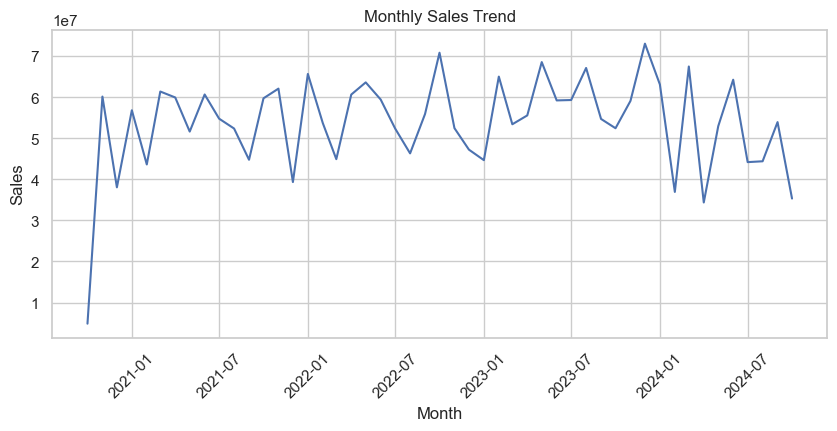

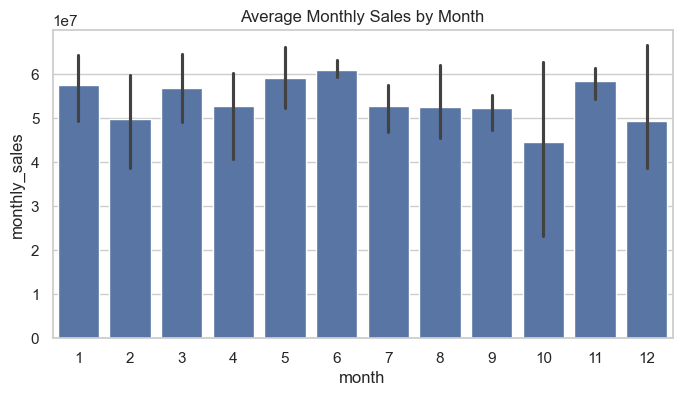

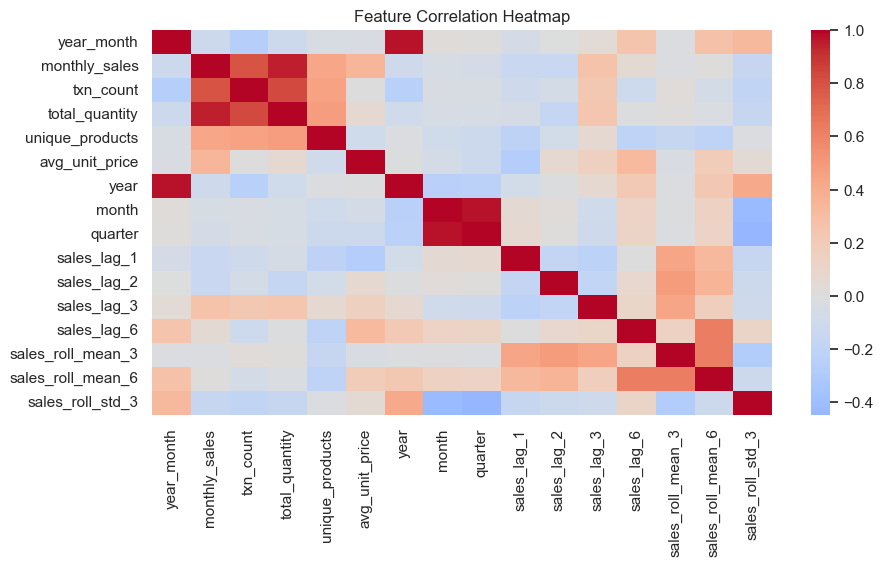

In [9]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales["year_month"], monthly_sales["monthly_sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=monthly_sales, x="month", y="monthly_sales", estimator=np.mean)
plt.title("Average Monthly Sales by Month")
plt.show()

plt.figure(figsize=(10,5))
sns.heatmap(model_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
test_months = 3

train_df = model_df.iloc[:-test_months]
test_df = model_df.iloc[-test_months:]

feature_cols = [
    c for c in model_df.columns
    if c not in ["year_month", "monthly_sales"]
]

X_train, y_train = train_df[feature_cols], train_df["monthly_sales"]
X_test, y_test = test_df[feature_cols], test_df["monthly_sales"]

In [15]:
baseline_pred = np.repeat(y_train.iloc[-1], len(y_test))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", rmse(y_test, baseline_pred))

Baseline MAE: 6275095.52600116
Baseline RMSE: 7610910.631762691


In [16]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, rf_pred))
print("RF RMSE:", rmse(y_test, rf_pred))


RF MAE: 2365386.434689266
RF RMSE: 3208556.6564220767


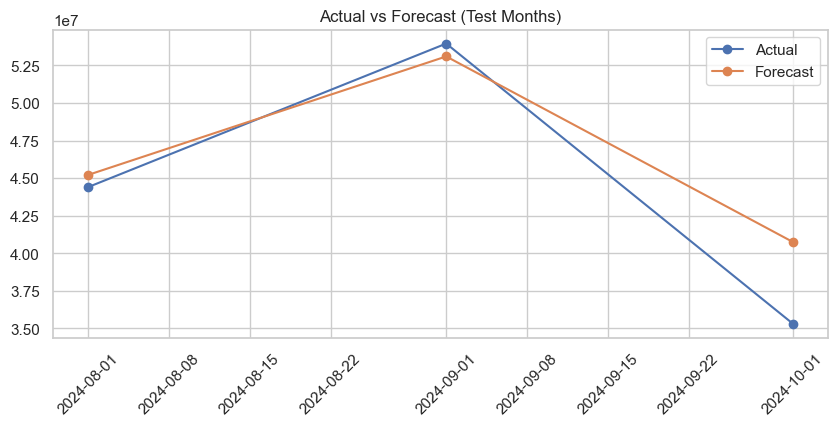

In [17]:
plt.figure(figsize=(10,4))
plt.plot(test_df["year_month"], y_test.values, marker="o", label="Actual")
plt.plot(test_df["year_month"], rf_pred, marker="o", label="Forecast")
plt.title("Actual vs Forecast (Test Months)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [18]:
future_months = 3
future_forecasts = []

history = monthly_sales.copy()

for _ in range(future_months):
    next_month = history["year_month"].max() + pd.offsets.MonthBegin(1)

    row = history.iloc[-1:].copy()
    row["year_month"] = next_month
    row["year"] = next_month.year
    row["month"] = next_month.month
    row["quarter"] = next_month.quarter

    for lag in [1,2,3,6]:
        row[f"sales_lag_{lag}"] = history["monthly_sales"].iloc[-lag]

    row["sales_roll_mean_3"] = history["monthly_sales"].tail(3).mean()
    row["sales_roll_mean_6"] = history["monthly_sales"].tail(6).mean()
    row["sales_roll_std_3"] = history["monthly_sales"].tail(3).std()

    X_future = row[feature_cols]
    forecast = rf.predict(X_future)[0]

    row["monthly_sales"] = forecast
    history = pd.concat([history, row], ignore_index=True)

    future_forecasts.append({
        "year_month": next_month,
        "forecast_sales": forecast
    })

future_df = pd.DataFrame(future_forecasts)
future_df

,year_month,forecast_sales
0,2024-11-01,4.116648e+07
1,2024-12-01,4.074658e+07
2,2025-01-01,4.024440e+07


In [23]:
OUTPUT_DIR = Path.cwd().parent / "MO-IT134 Week 8 Homework: Initial Project Forecasting Model BSIT-A3101 Atienza T."
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_df.to_csv(OUTPUT_DIR / "monthly_sales_features.csv", index=False)
future_df.to_csv(OUTPUT_DIR / "sales_forecast_next_3_months.csv", index=False)

OUTPUT_DIR

PosixPath('/Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Week 8 Homework: Initial Project Forecasting Model BSIT-A3101 Atienza T.')

## Interpretation and Model Justification

The Random Forest forecasting model outperforms the naive baseline, indicating that
engineered lag, rolling, and transaction activity features provide useful predictive signals.

### Business Insight
- Sales exhibit clear seasonal and momentum-driven behaviour.
- Recent months strongly influence near-term sales forecasts.
- The forecast can be used for planning inventory, staffing, and revenue targets.

### Next Improvements
- Compare against SARIMAX / ARIMA
- Tune hyperparameters
- Add promotional or campaign data if available